In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv("Housing_Price_data.csv")
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [ ]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:
df.describe(include="object")

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
count,545,545,545,545,545,545,545
unique,2,2,2,2,2,2,3
top,yes,no,no,no,no,no,semi-furnished
freq,468,448,354,520,373,417,227


In [ ]:
df['mainroad'].value_counts()

,count
mainroad,
yes,468
no,77


In [ ]:
df['guestroom'].unique()

array(['no', 'yes'], dtype=object)

In [ ]:
df1=df

In [ ]:
x=df1.drop(columns=['price'],axis=1)
y=df1['price']

In [ ]:


from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df1["furnishingstatus"]=le.fit_transform(df1["furnishingstatus"])
df1["prefarea"]=le.fit_transform(df1["prefarea"])
df1["airconditioning"]=le.fit_transform(df1["airconditioning"])
df1["hotwaterheating"]=le.fit_transform(df1["hotwaterheating"])
df1["basement"]=le.fit_transform(df1["basement"])
df1["guestroom"]=le.fit_transform(df1["guestroom"])
df1["mainroad"]=le.fit_transform(df1["mainroad"])

<Axes: >

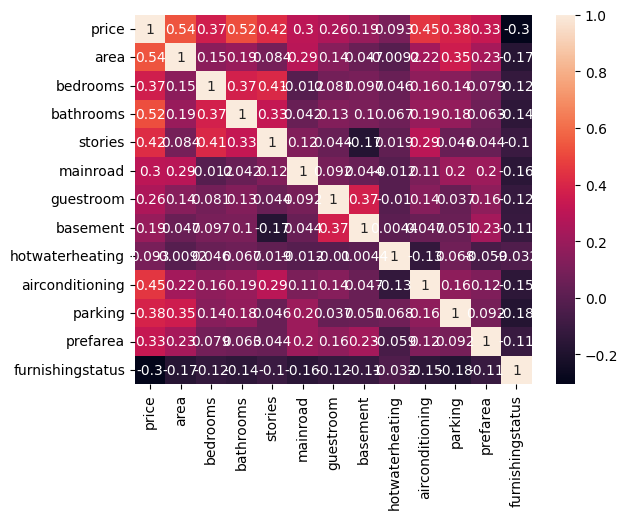

In [ ]:
sns.heatmap(df1.corr(),annot=True)

In [ ]:
cat_cols=["furnishingstatus"]
X_final=pd.get_dummies(x,columns=cat_cols,drop_first=True)
X_final

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_1,furnishingstatus_2
0,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,7420,4,1,2,1,1,1,0,1,2,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,1,0,1,0,0,2,0,False,True
541,2400,3,1,1,0,0,0,0,0,0,0,True,False
542,3620,2,1,1,1,0,0,0,0,0,0,False,True
543,2910,3,1,1,0,0,0,0,0,0,0,False,False


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
std_scalar=StandardScaler()
x_train_scaled=std_scalar.fit_transform(X_final)
y=std_scalar.fit_transform(y.values.reshape(-1,1))


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x_train_scaled,y,random_state=42, test_size=0.2)
print("X test Shape:",X_test.shape)
print("X train Shape:",X_train.shape)
print("y test Shape:",y_test.shape)
print("y train Shape:",y_train.shape)

X test Shape: (109, 13)
X train Shape: (436, 13)
y test Shape: (109, 1)
y train Shape: (436, 1)


array([[-0.37818837],
       [ 1.00778496],
       [-0.56548207],
       [ 0.89540874],
       [-1.05244567],
       [ 0.07131649],
       [ 0.25861018],
       [-0.11972308],
       [-1.23973936],
       [-0.75652163],
       [ 2.88072189],
       [-1.12736315],
       [-0.75277576],
       [-0.75277576],
       [-1.33338621],
       [-1.12736315],
       [-1.12736315],
       [ 1.38237234],
       [-0.97752819],
       [-1.01498693],
       [ 1.04524369],
       [ 0.35225703],
       [-1.53940927],
       [ 0.25861018],
       [-0.30701677],
       [ 4.00448405],
       [-0.90261071],
       [ 0.18369271],
       [ 2.69342819],
       [-1.20228062],
       [ 1.08270243],
       [-0.67785828],
       [ 1.00778496],
       [-0.97752819],
       [-0.77150513],
       [-0.3032709 ],
       [ 0.07131649],
       [-0.7902345 ],
       [-0.67785828],
       [-1.2771981 ],
       [ 0.38971577],
       [-0.58421144],
       [ 1.00778496],
       [ 0.07506236],
       [-0.86515198],
       [-0

In [ ]:
import tensorflow as tf

In [ ]:
from tensorflow import keras
import pandas as pd
import numpy as np
import keras
from keras.models import Sequential
from keras.layers import Dense

In [ ]:
from keras.layers import Input, Dense, Dropout
from keras.models import Sequential

In [ ]:
regressor = Sequential()
regressor.add(Input(shape=(13,)))  # Explicit input layer
regressor.add(Dense(64, kernel_initializer="uniform", activation="relu"))
regressor.add(Dense(128, kernel_initializer="uniform", activation="relu"))
regressor.add(Dense(64, kernel_initializer="uniform", activation="relu"))
regressor.add(Dense(1, kernel_initializer="uniform", activation="linear"))

regressor.compile(optimizer="adam", loss="mean_squared_error", metrics=["r2_score"])

In [ ]:
regressor = Sequential()
regressor.add(Input(shape=(13,)))  # Explicit input layer
regressor.add(Dense(64, kernel_initializer="uniform", activation="relu"))
regressor.add(Dropout(0.2))
regressor.add(Dense(128, kernel_initializer="uniform", activation="relu"))
regressor.add(Dropout(0.3))
regressor.add(Dense(64, kernel_initializer="uniform", activation="relu"))
regressor.add(Dropout(0.1))
regressor.add(Dense(1, kernel_initializer="uniform", activation="linear"))

regressor.compile(optimizer="adam", loss="mean_squared_error", metrics=["r2_score"])

In [ ]:
regressor.fit(X_train, y_train,validation_data=(X_test,y_test), batch_size = 32, epochs = 100)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.1307 - r2_score: 0.8448 - val_loss: 0.5320 - val_r2_score: 0.6324
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1206 - r2_score: 0.8747 - val_loss: 0.5639 - val_r2_score: 0.6104
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1353 - r2_score: 0.8422 - val_loss: 0.5534 - val_r2_score: 0.6177
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1242 - r2_score: 0.8419 - val_loss: 0.5466 - val_r2_score: 0.6223
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1269 - r2_score: 0.8464 - val_loss: 0.5309 - val_r2_score: 0.6332
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.1301 - r2_score: 0.8638 - val_loss: 0.5393 - val_r2_score: 0.6274
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1244 - r2_score: 0.8564 - val_loss: 0.5171 - val_r2_score: 0.6428
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1134 - r2_score: 0.8825 - val_loss: 0.5484

In [ ]:
y_pred = regressor.predict(X_test)
y_pred

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


array([[ 0.18635222],
       [ 1.5398678 ],
       [-0.6077775 ],
       [-0.17871393],
       [-0.54731375],
       [-0.90581584],
       [-0.09042925],
       [ 0.57586694],
       [-0.9850249 ],
       [-0.8752816 ],
       [ 2.7113414 ],
       [-0.94745743],
       [-0.84560364],
       [-0.7125062 ],
       [-0.71218455],
       [-0.29402888],
       [-0.8139122 ],
       [-0.03146535],
       [ 0.37214783],
       [-0.5157118 ],
       [ 0.5191317 ],
       [ 0.57565117],
       [-0.97786033],
       [ 0.09166808],
       [-0.22244126],
       [ 1.6048619 ],
       [-0.45806766],
       [-0.319212  ],
       [ 1.3784188 ],
       [-0.68291366],
       [ 1.0932633 ],
       [-0.81041676],
       [ 0.76548886],
       [-0.431327  ],
       [-1.0046147 ],
       [ 1.026624  ],
       [-0.26624677],
       [-0.4654261 ],
       [-0.8626268 ],
       [-0.4312479 ],
       [-0.3290829 ],
       [-0.85744226],
       [ 1.5311135 ],
       [-0.22752531],
       [-0.5276034 ],
       [-0

In [ ]:
y_pred_reg = (y_pred > 0.5)
y_pred_reg

array([[False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Absolute Error: 0.5417351697214862
Mean Squared Error: 0.5565884082843081
R-squared: 0.6154616109365283


In [ ]:
regressor.evaluate(X_test,y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5271 - r2_score: 0.6457


[0.5565884113311768, 0.6154615879058838]

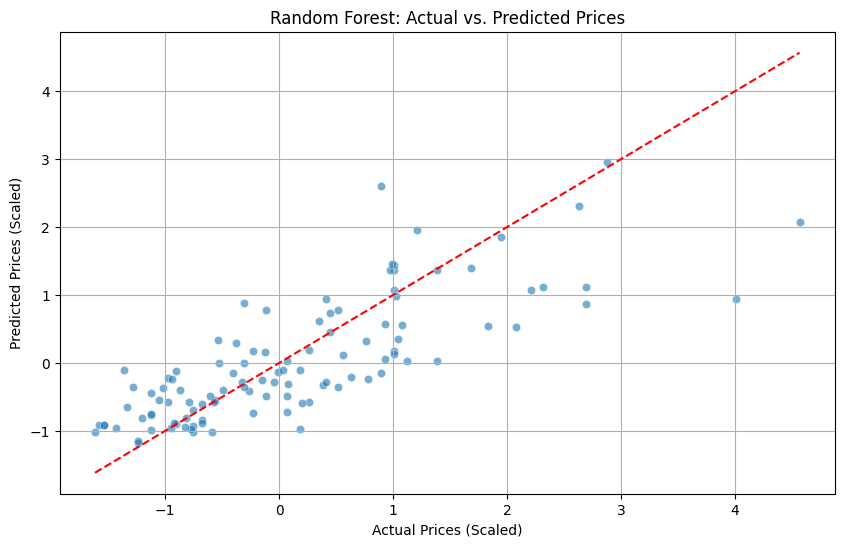

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test.flatten(), y=y_pred_rf.flatten(), alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('Random Forest: Actual vs. Predicted Prices')
plt.xlabel('Actual Prices (Scaled)')
plt.ylabel('Predicted Prices (Scaled)')
plt.grid(True)
plt.show()

# Task
Initialize a RandomForestRegressor model, train it using X_train and y_train, make predictions on X_test, and then evaluate its performance by calculating Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2) score. Finally, summarize the Random Forest model's performance and compare it with the neural network model.

## Initialize and Train Random Forest Model

### Subtask:
Initialize a RandomForestRegressor model and train it using the scaled training data (X_train and y_train).


**Reasoning**:
To initialize and train a RandomForestRegressor model, I need to import the class, instantiate it, and then fit it to the training data. I will reshape `y_train` using `.ravel()` as it's currently a 2D array.



In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the RandomForestRegressor model
rf_regressor = RandomForestRegressor(random_state=42)

# Train the model
rf_regressor.fit(X_train, y_train.ravel())

RandomForestRegressor(random_state=42)

**Reasoning**:
Now that the RandomForestRegressor model has been trained, I need to use it to make predictions on the test set (`X_test`). This will generate the predicted target values that can then be compared with the actual target values (`y_test`) for evaluation.



In [ ]:
y_pred_rf = rf_regressor.predict(X_test)
y_pred_rf

array([ 2.90712322e-01,  1.36248175e+00, -5.38024812e-01, -1.45457231e-01,
       -5.43194118e-01, -7.20860915e-01,  1.92495509e-01,  1.56872249e-01,
       -1.17422403e+00, -1.01008358e+00,  2.95226808e+00, -7.59015316e-01,
       -9.27271051e-01, -6.89582868e-01, -6.49052513e-01, -4.47000077e-01,
       -7.52382444e-01,  3.46069258e-02, -5.72037346e-01, -3.66594894e-01,
        3.56021633e-01,  6.21472984e-01, -9.09815279e-01, -5.78255497e-01,
        3.69638709e-04,  9.38486289e-01, -8.96167812e-01, -9.67983293e-02,
        8.66453135e-01, -8.15144560e-01,  5.61801213e-01, -8.32974920e-01,
        1.06936712e+00, -2.22697150e-01, -9.77228522e-01,  8.78777060e-01,
        3.40450447e-02, -5.78611355e-01, -8.87514843e-01, -3.47434750e-01,
       -3.21850431e-01, -1.02201044e+00,  1.44020863e+00, -3.06679642e-01,
       -3.90287547e-01, -2.48019257e-01,  1.36383027e+00, -3.56050259e-01,
       -9.55614830e-01, -9.05008074e-01,  1.84723529e+00, -1.14586776e+00,
       -4.11189523e-01, -

**Reasoning**:
Now that predictions have been made with the Random Forest model, I will evaluate its performance using Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2) score. This will allow for a comparison with the previously trained neural network model.



In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest - Mean Absolute Error:", mae_rf)
print("Random Forest - Mean Squared Error:", mse_rf)
print("Random Forest - R-squared:", r2_rf)

Random Forest - Mean Absolute Error: 0.5469384302953818
Random Forest - Mean Squared Error: 0.5638971432308411
Random Forest - R-squared: 0.61041211813251


### Random Forest Model Performance Summary and Comparison with Neural Network

**Random Forest Model Metrics:**
- Mean Absolute Error (MAE): 0.5469
- Mean Squared Error (MSE): 0.5639
- R-squared (R2): 0.6104

**Neural Network Model Metrics:**
- Mean Absolute Error (MAE): 0.5417
- Mean Squared Error (MSE): 0.5566
- R-squared (R2): 0.6155

**Comparison:**
Both the Random Forest and the Neural Network models show comparable performance. The Neural Network model achieved a slightly higher R-squared score (0.6155) compared to the Random Forest model (0.6104), indicating that it explains a marginally larger proportion of the variance in the target variable. Similarly, the Neural Network also has slightly lower MAE and MSE values, suggesting slightly better overall accuracy in its predictions than the Random Forest model. However, the differences are minimal, implying both models are performing at a similar level on this dataset.

## Summary:

### Q&A
The Random Forest model's performance is as follows: Mean Absolute Error (MAE) of 0.5469, Mean Squared Error (MSE) of 0.5639, and an R-squared (R2) score of 0.6104.

When compared to the Neural Network model, which had an MAE of 0.5417, MSE of 0.5566, and an R2 score of 0.6155, both models show comparable performance. The Neural Network model performed marginally better with a slightly higher R2 score and slightly lower MAE and MSE, indicating it explained a slightly larger proportion of variance and had slightly better accuracy, though the differences were minimal.

### Data Analysis Key Findings
*   A RandomForestRegressor model was successfully initialized and trained, achieving the following performance metrics:
    *   Mean Absolute Error (MAE): 0.5469
    *   Mean Squared Error (MSE): 0.5639
    *   R-squared (R2): 0.6104
*   The Random Forest model and a Neural Network model exhibited comparable performance on the dataset.
*   The Neural Network model showed a slightly better R-squared score (0.6155) compared to the Random Forest model (0.6104), suggesting it explained a marginally greater proportion of the variance.
*   The Neural Network also had slightly lower MAE (0.5417) and MSE (0.5566) than the Random Forest model, indicating marginally better prediction accuracy.

### Insights or Next Steps
*   Given the minimal performance difference, further investigation into model complexity or interpretability might be beneficial for choosing between Random Forest and Neural Network for this specific task.
*   Consider exploring hyperparameter tuning for both models to potentially achieve better performance, as the current differences are marginal and could be influenced by default parameters.
